In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
sns.set(rc={'figure.figsize':(11.7,8.27)})

In [3]:
cars_data=pd.read_csv("C:\\Users\\srini\\Downloads\\cars_sampled.csv")

In [4]:
cars=cars_data.copy()

In [5]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50001 entries, 0 to 50000
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   dateCrawled          50001 non-null  object
 1   name                 50001 non-null  object
 2   seller               50001 non-null  object
 3   offerType            50001 non-null  object
 4   price                50001 non-null  int64 
 5   abtest               50001 non-null  object
 6   vehicleType          44813 non-null  object
 7   yearOfRegistration   50001 non-null  int64 
 8   gearbox              47177 non-null  object
 9   powerPS              50001 non-null  int64 
 10  model                47243 non-null  object
 11  kilometer            50001 non-null  int64 
 12  monthOfRegistration  50001 non-null  int64 
 13  fuelType             45498 non-null  object
 14  brand                50001 non-null  object
 15  notRepairedDamage    40285 non-null  object
 16  date

In [6]:
cars.describe()

,price,yearOfRegistration,powerPS,kilometer,monthOfRegistration,postalCode
count,5.000100e+04,50001.000000,50001.000000,50001.000000,50001.000000,50001.000000
mean,6.559865e+03,2005.544229,116.496130,125613.687726,5.743725,50775.216696
std,8.581847e+04,122.991832,230.567709,40205.234483,3.711345,25743.701933
min,0.000000e+00,1000.000000,0.000000,5000.000000,0.000000,1067.000000
25%,1.150000e+03,1999.000000,69.000000,125000.000000,3.000000,30559.000000
50%,2.950000e+03,2003.000000,105.000000,150000.000000,6.000000,49504.000000
75%,7.190000e+03,2008.000000,150.000000,150000.000000,9.000000,71404.000000
max,1.234568e+07,9999.000000,19312.000000,150000.000000,12.000000,99998.000000


In [7]:
pd.set_option('display.float_format',lambda x:"%.3f" %x)

In [8]:
cars.describe()

,price,yearOfRegistration,powerPS,kilometer,monthOfRegistration,postalCode
count,50001.000,50001.000,50001.000,50001.000,50001.000,50001.000
mean,6559.865,2005.544,116.496,125613.688,5.744,50775.217
std,85818.470,122.992,230.568,40205.234,3.711,25743.702
min,0.000,1000.000,0.000,5000.000,0.000,1067.000
25%,1150.000,1999.000,69.000,125000.000,3.000,30559.000
50%,2950.000,2003.000,105.000,150000.000,6.000,49504.000
75%,7190.000,2008.000,150.000,150000.000,9.000,71404.000
max,12345678.000,9999.000,19312.000,150000.000,12.000,99998.000


In [9]:
pd.set_option('display.max_columns',500)


In [10]:
cars.describe()

,price,yearOfRegistration,powerPS,kilometer,monthOfRegistration,postalCode
count,50001.000,50001.000,50001.000,50001.000,50001.000,50001.000
mean,6559.865,2005.544,116.496,125613.688,5.744,50775.217
std,85818.470,122.992,230.568,40205.234,3.711,25743.702
min,0.000,1000.000,0.000,5000.000,0.000,1067.000
25%,1150.000,1999.000,69.000,125000.000,3.000,30559.000
50%,2950.000,2003.000,105.000,150000.000,6.000,49504.000
75%,7190.000,2008.000,150.000,150000.000,9.000,71404.000
max,12345678.000,9999.000,19312.000,150000.000,12.000,99998.000


In [11]:
col=['name','dateCrawled','dateCreated','postalCode','lastSeen']
cars=cars.drop(columns=col,axis=1)

In [12]:
cars.drop_duplicates(keep='first',inplace=True)


In [13]:
cars.isnull().sum()

seller                    0
offerType                 0
price                     0
abtest                    0
vehicleType            5152
yearOfRegistration        0
gearbox                2765
powerPS                   0
model                  2730
kilometer                 0
monthOfRegistration       0
fuelType               4467
brand                     0
notRepairedDamage      9640
dtype: int64

In [14]:
yearwise_count=cars['yearOfRegistration'].value_counts().sort_index()
print(yearwise_count)


1000     6
1255     1
1500     2
1910    14
1928     1
        ..
7500     1
7800     1
8500     1
8888     2
9999     7
Name: yearOfRegistration, Length: 97, dtype: int64


In [15]:
sum(cars['yearOfRegistration']>2018)


26

In [16]:
sum(cars['yearOfRegistration']<1950)

38

<AxesSubplot:xlabel='yearOfRegistration', ylabel='price'>

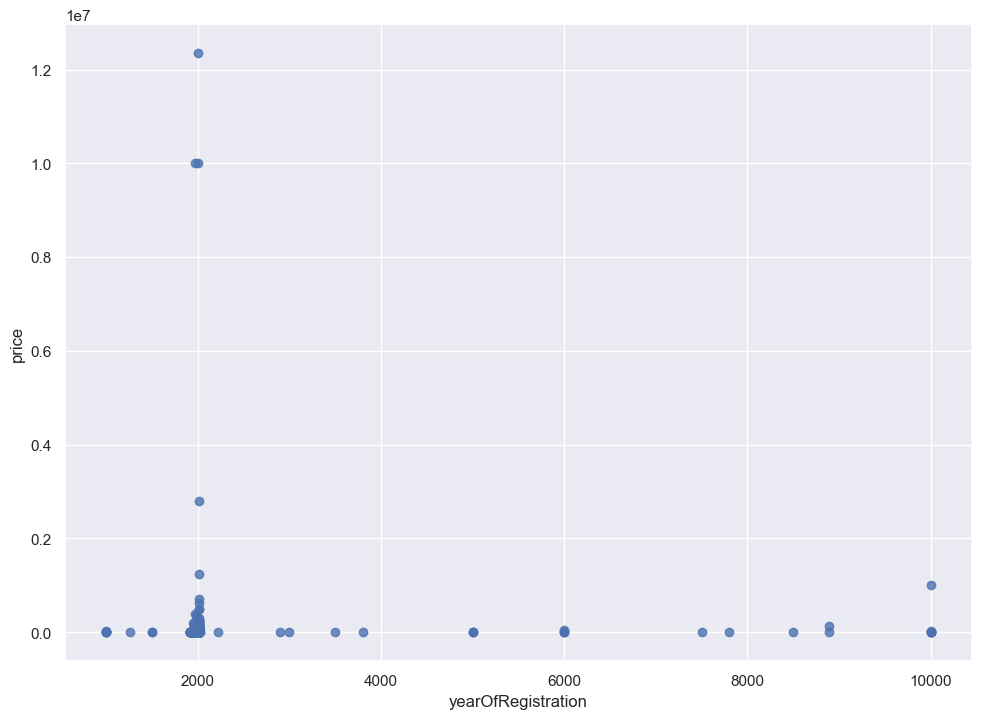

In [17]:
sns.regplot(x='yearOfRegistration',y='price',scatter=True,fit_reg=False,data=cars)


In [18]:
price_count=cars['price'].value_counts().sort_index()
print(price_count)

0           1415
1            172
2              1
3              1
5              4
            ... 
1250000        1
2795000        1
9999999        1
10010011       1
12345678       1
Name: price, Length: 2393, dtype: int64


C:\Users\srini\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='price', ylabel='Density'>

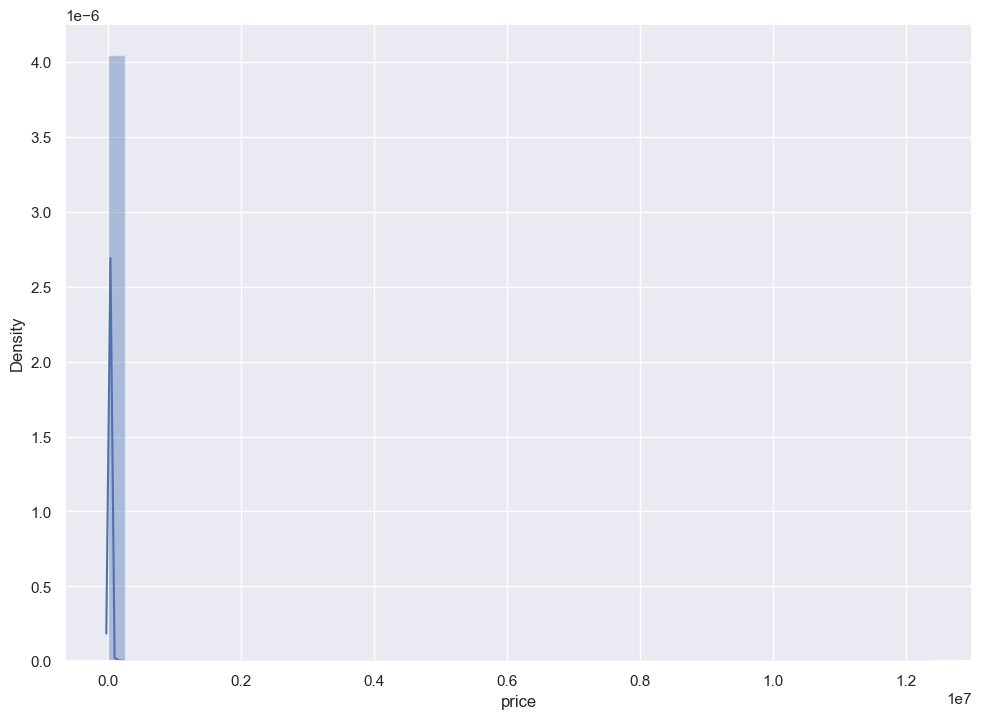

In [19]:
sns.distplot(cars['price'])

In [20]:
cars['price'].describe()

count      49531.000
mean        6567.220
std        86222.378
min            0.000
25%         1150.000
50%         2950.000
75%         7100.000
max     12345678.000
Name: price, dtype: float64

<AxesSubplot:ylabel='price'>

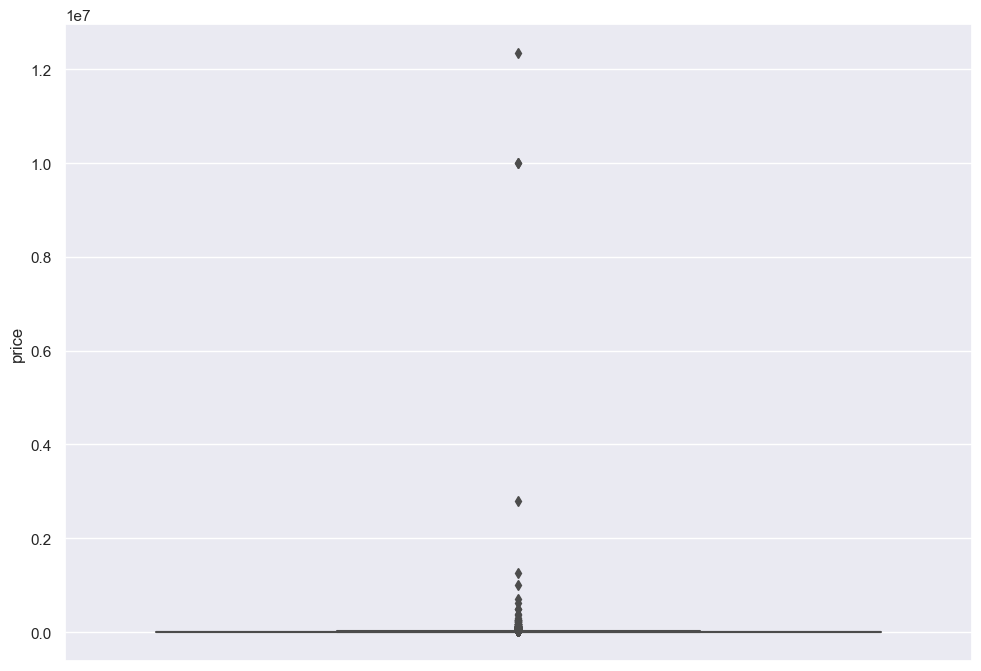

In [21]:
sns.boxplot(y=cars['price'])

In [22]:
sum(cars['price']>150000)

34

In [23]:
sum(cars['price']<100)

1748

In [24]:
power_count=cars['powerPS'].value_counts().sort_index()
print(power_count)

0        5533
1           3
2           2
3           2
4           4
         ... 
15033       1
16011       1
16312       1
19211       1
19312       1
Name: powerPS, Length: 460, dtype: int64


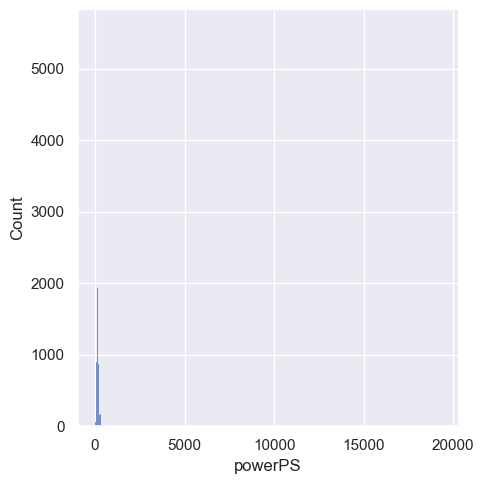

In [25]:
sns.displot(cars['powerPS'])

In [26]:
cars['powerPS'].describe()

count   49531.000
mean      116.501
std       231.536
min         0.000
25%        69.000
50%       105.000
75%       150.000
max     19312.000
Name: powerPS, dtype: float64

<AxesSubplot:ylabel='powerPS'>

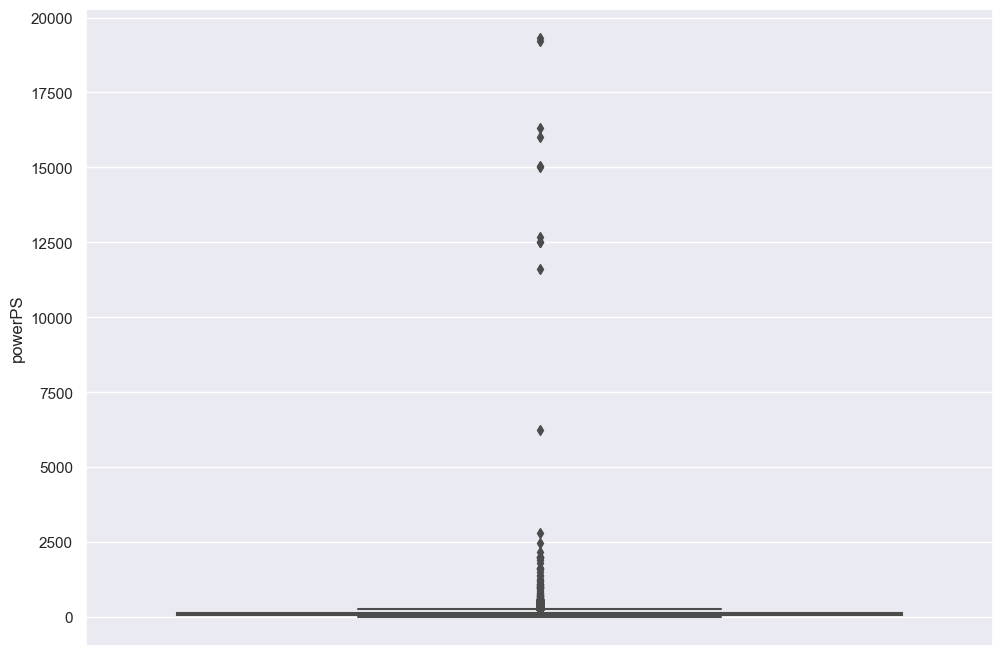

In [27]:
sns.boxplot(y=cars['powerPS'])

<AxesSubplot:xlabel='powerPS', ylabel='price'>

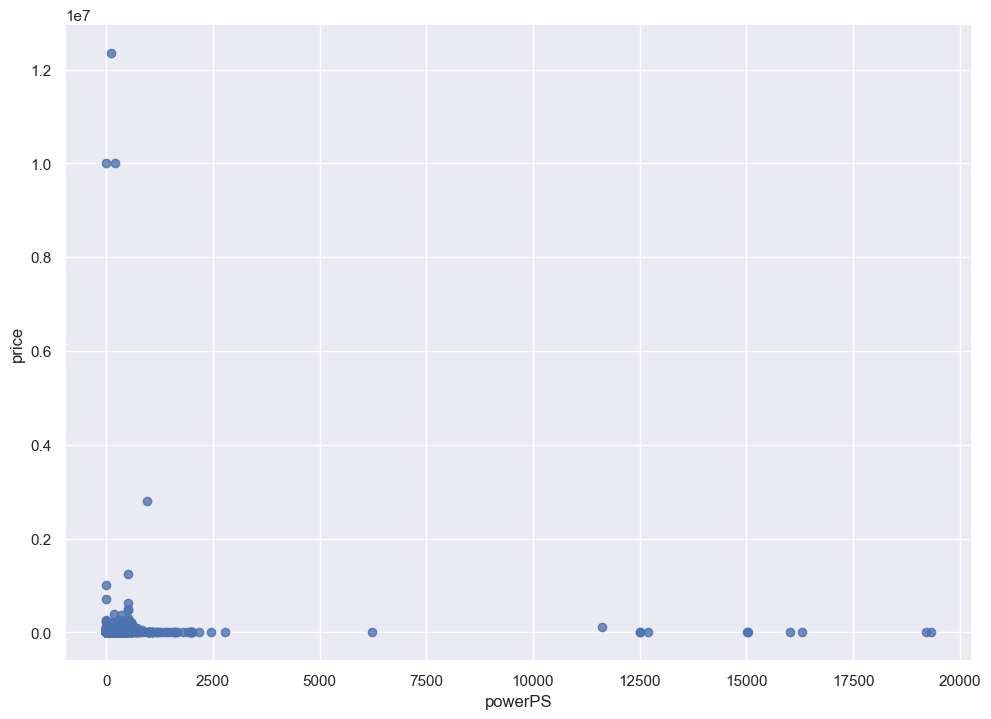

In [28]:
sns.regplot(x='powerPS',y='price',scatter=True,fit_reg=False,data=cars)

In [29]:
sum(cars['powerPS']>500)

115

In [30]:
sum(cars['powerPS']<10)

5565

In [31]:
cars=cars[
     (cars.yearOfRegistration <=2018) 
    &(cars.yearOfRegistration >=1950)
    &(cars.price >=100) 
    &(cars.price <=150000)
    &(cars.powerPS >=10) 
    &(cars.price <=500)]
cars['monthOfRegistration']/=12
cars['Age']=(2018-cars['yearOfRegistration'])+cars['monthOfRegistration']
cars['Age']=round(cars['Age'],2)
cars['Age'].describe()


count   2720.000
mean      19.343
std        6.700
min        0.000
25%       18.330
50%       20.920
75%       23.000
max       48.170
Name: Age, dtype: float64

In [32]:
cars=cars.drop(columns=['yearOfRegistration','monthOfRegistration'],axis=1)

In [33]:
print(cars.describe())

         price   powerPS  kilometer      Age
count 2720.000  2720.000   2720.000 2720.000
mean   350.375    90.150 138988.971   19.343
std    124.148   252.007  30326.285    6.700
min    100.000    14.000   5000.000    0.000
25%    250.000    60.000 150000.000   18.330
50%    350.000    75.000 150000.000   20.920
75%    490.000   101.000 150000.000   23.000
max    500.000 12684.000 150000.000   48.170


C:\Users\srini\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Age', ylabel='Density'>

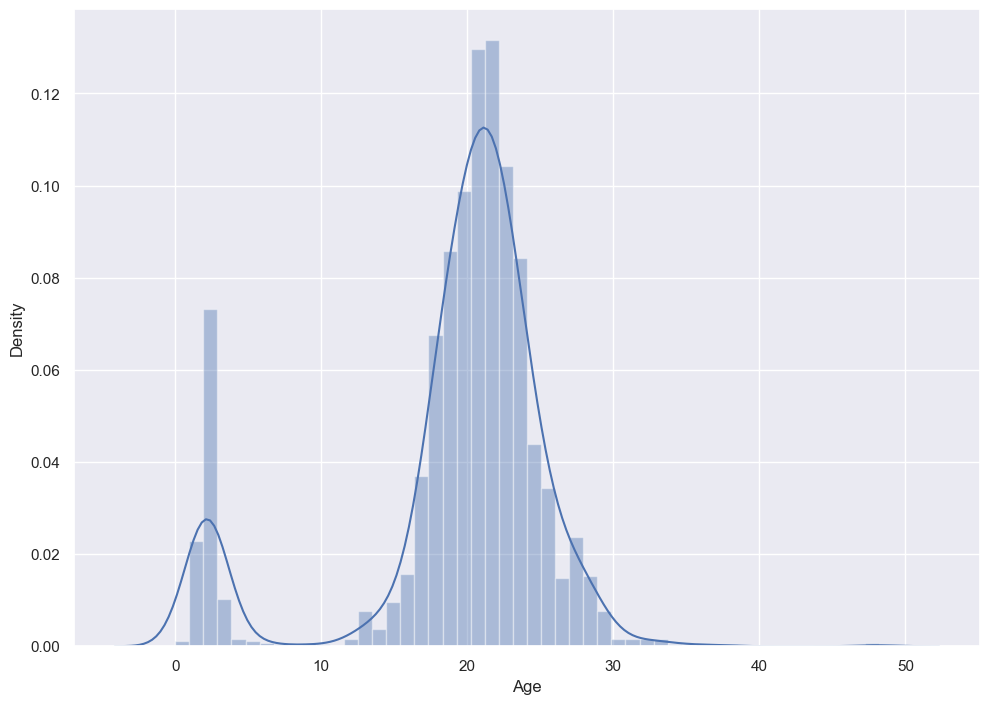

In [34]:
sns.distplot(cars['Age'])

<AxesSubplot:ylabel='Age'>

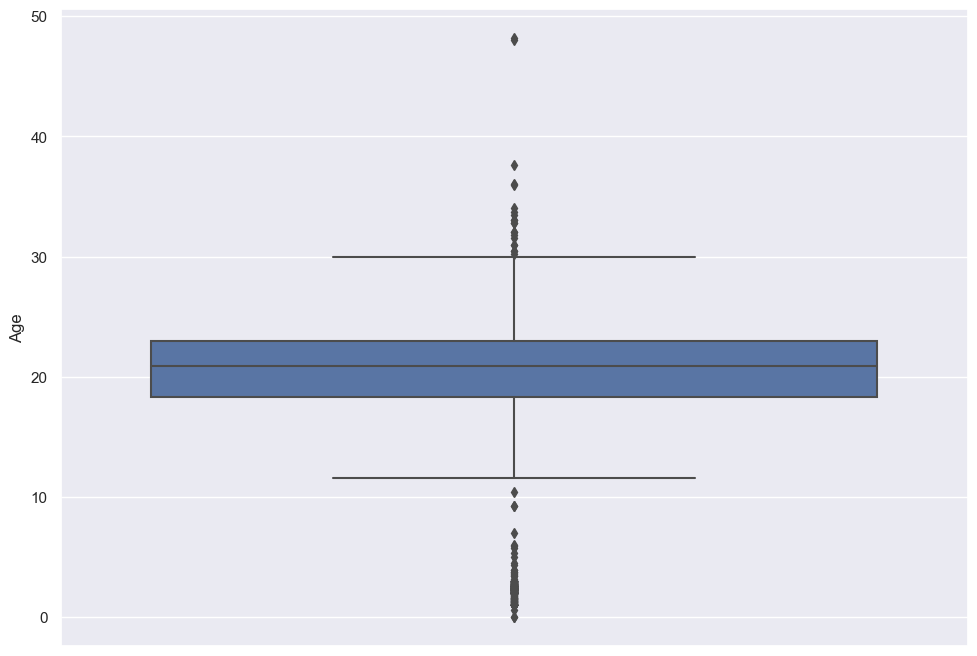

In [35]:
sns.boxplot(y=cars['Age'])

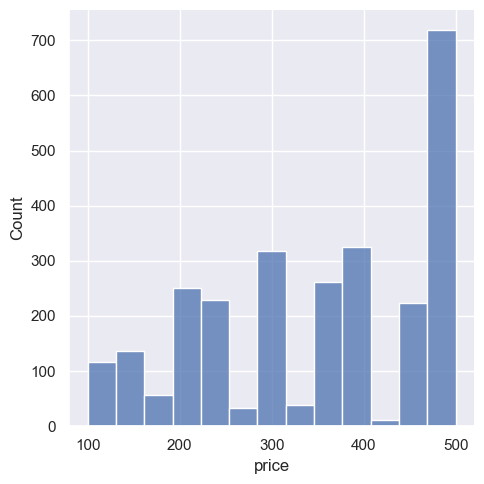

In [36]:
sns.displot(cars['price'])

<AxesSubplot:ylabel='price'>

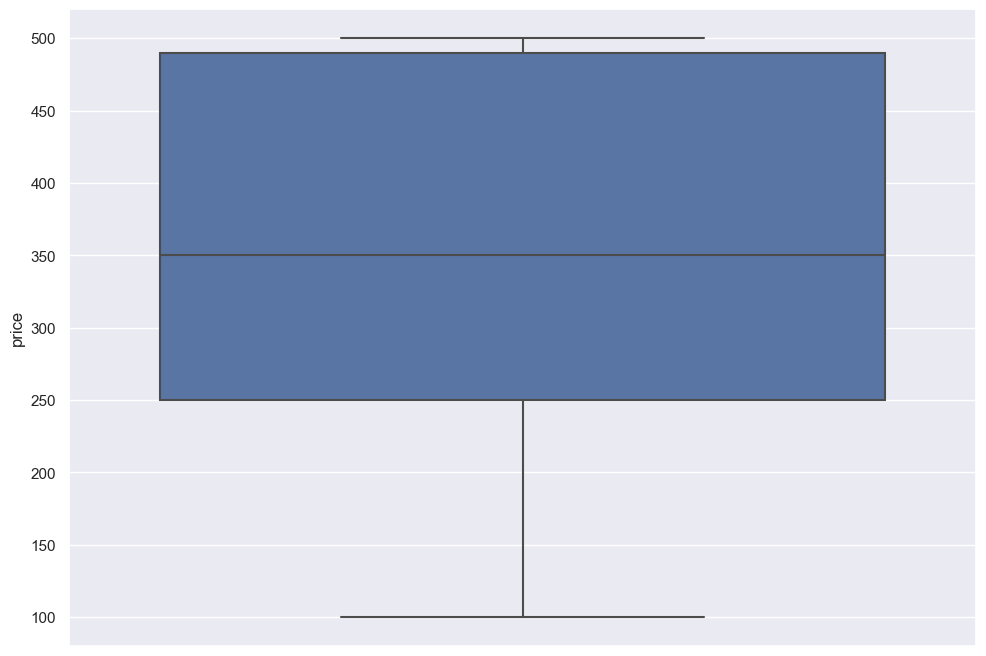

In [37]:
sns.boxplot(y=cars['price'])

<AxesSubplot:xlabel='Age', ylabel='price'>

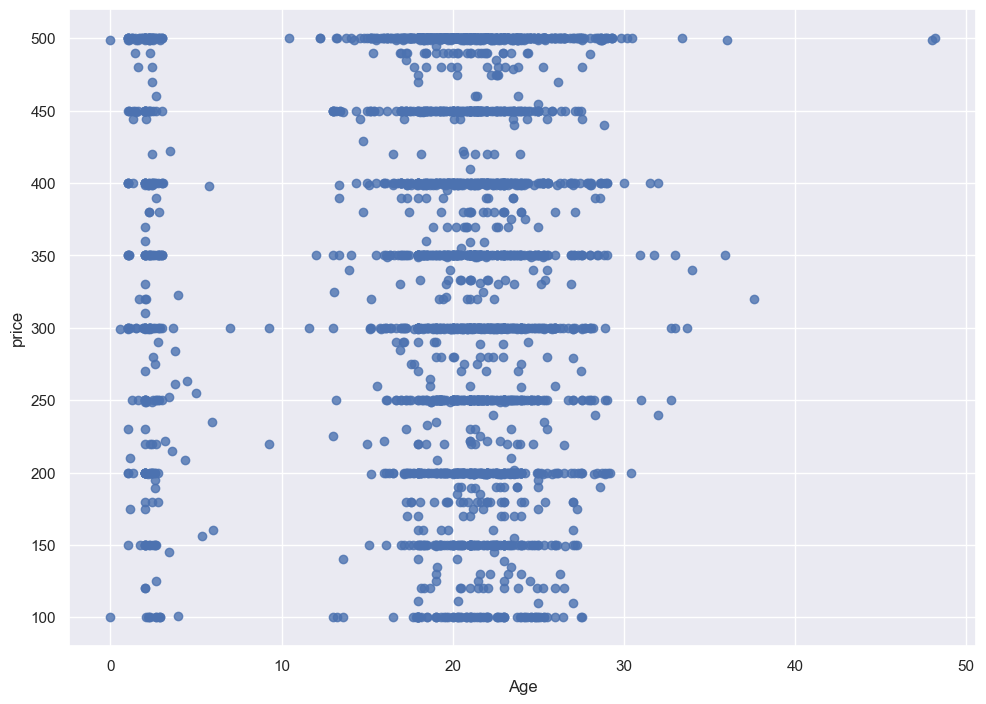

In [38]:
sns.regplot(x='Age',y='price',scatter=True,fit_reg=False,data=cars)

<AxesSubplot:xlabel='powerPS', ylabel='price'>

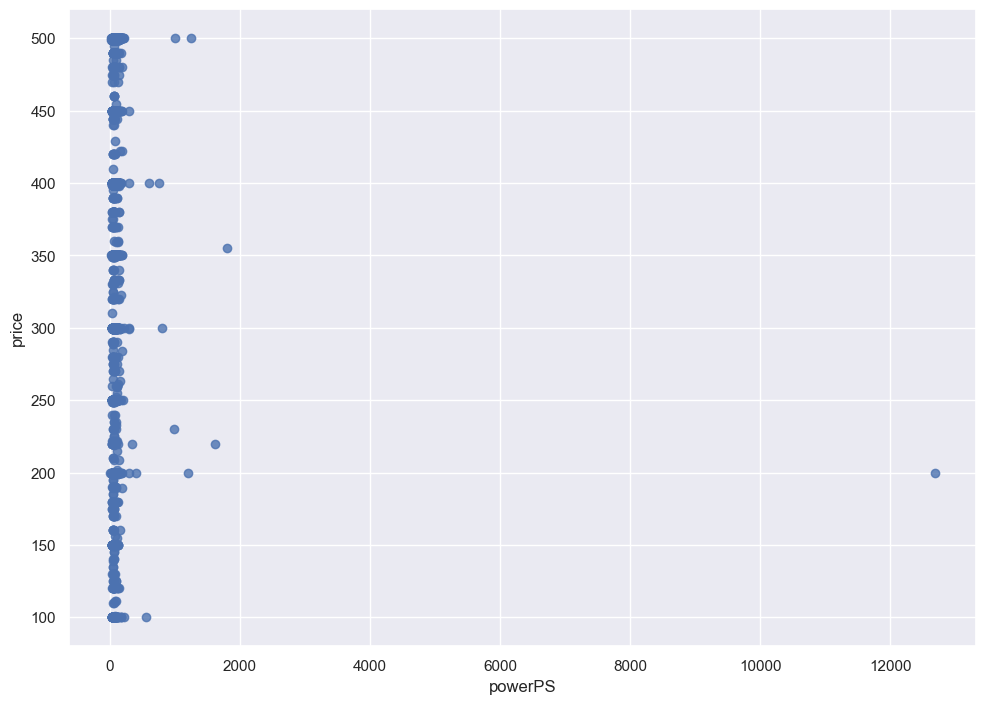

In [39]:
sns.regplot(x='powerPS',y='price',scatter=True,fit_reg=False,data=cars)

In [40]:
cars['seller'].value_counts()

private    2720
Name: seller, dtype: int64

In [41]:
pd.crosstab(cars['seller'],columns='count',normalize=True)

col_0,count
seller,
private,1.000


<AxesSubplot:xlabel='seller', ylabel='count'>

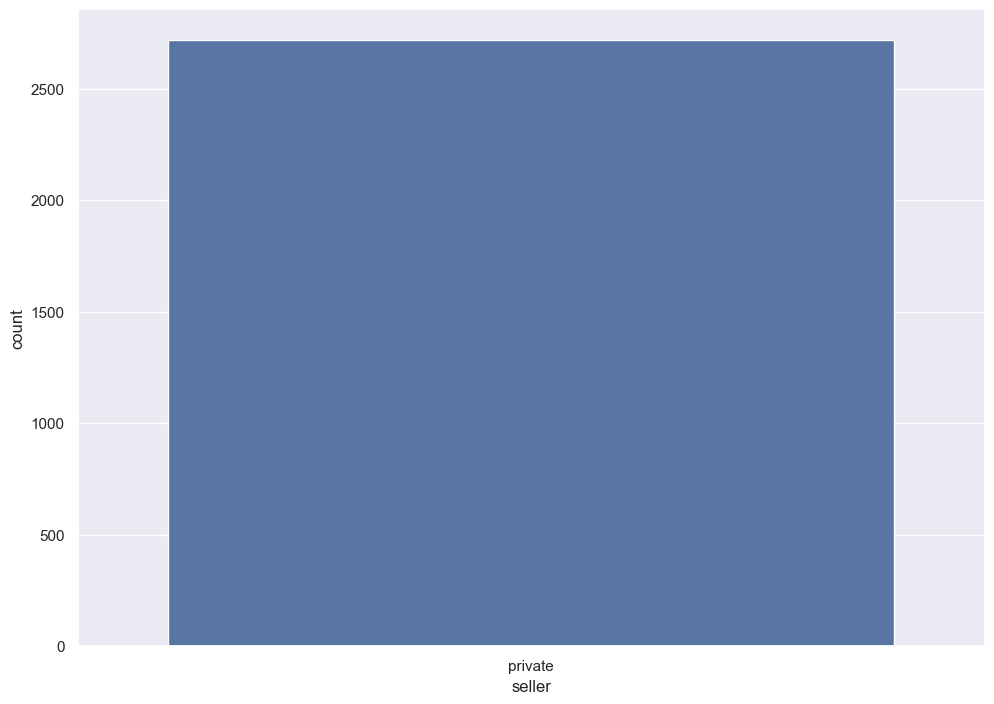

In [42]:
sns.countplot(x='seller',data=cars)

In [43]:
cars['offerType'].value_counts()

offer    2720
Name: offerType, dtype: int64

In [44]:
pd.crosstab(cars['abtest'],columns='count',normalize=True)

col_0,count
abtest,
control,0.482
test,0.518


<AxesSubplot:xlabel='abtest', ylabel='count'>

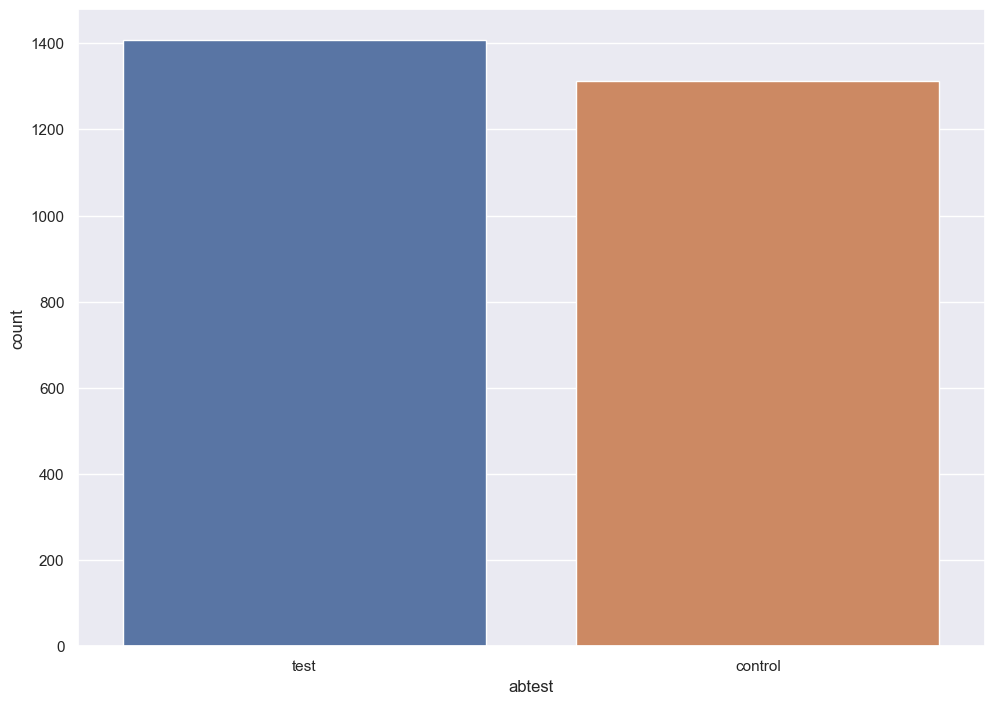

In [45]:
sns.countplot(x='abtest',data=cars)

<AxesSubplot:xlabel='abtest', ylabel='price'>

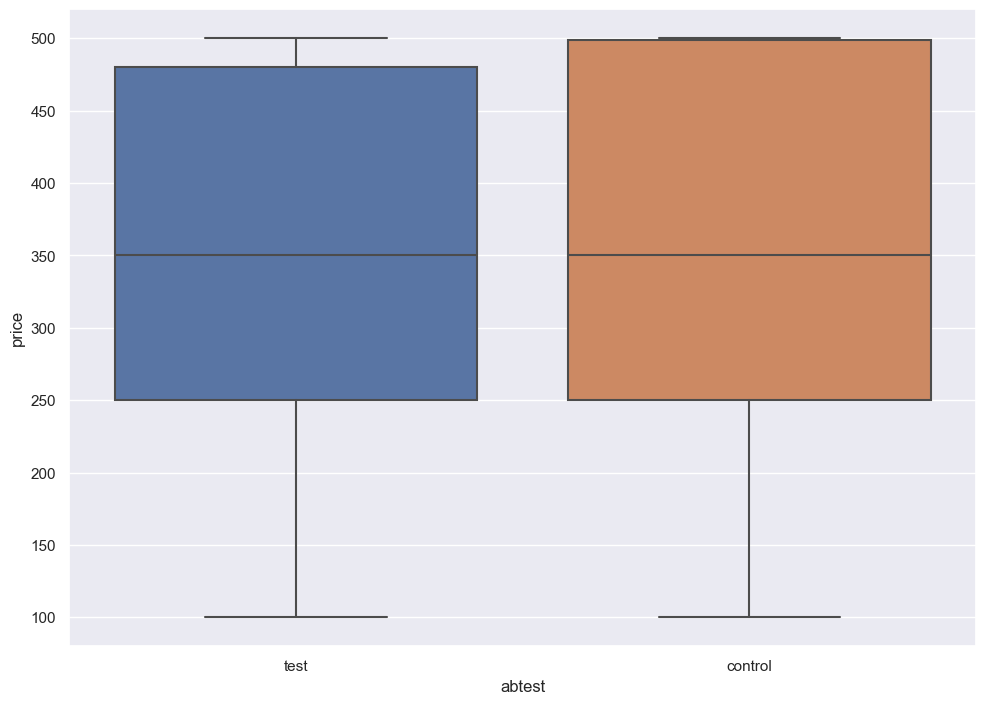

In [46]:
sns.boxplot(x='abtest',y='price',data=cars)

In [47]:
cars['vehicleType'].value_counts()

small car        1128
limousine         543
station wagon     381
coupe              89
bus                53
cabrio             37
others             33
suv                 7
Name: vehicleType, dtype: int64

In [48]:
pd.crosstab(cars['vehicleType'],columns='count',normalize=True)

col_0,count
vehicleType,
bus,0.023
cabrio,0.016
coupe,0.039
limousine,0.239
others,0.015
small car,0.497
station wagon,0.168
suv,0.003


<AxesSubplot:xlabel='vehicleType', ylabel='count'>

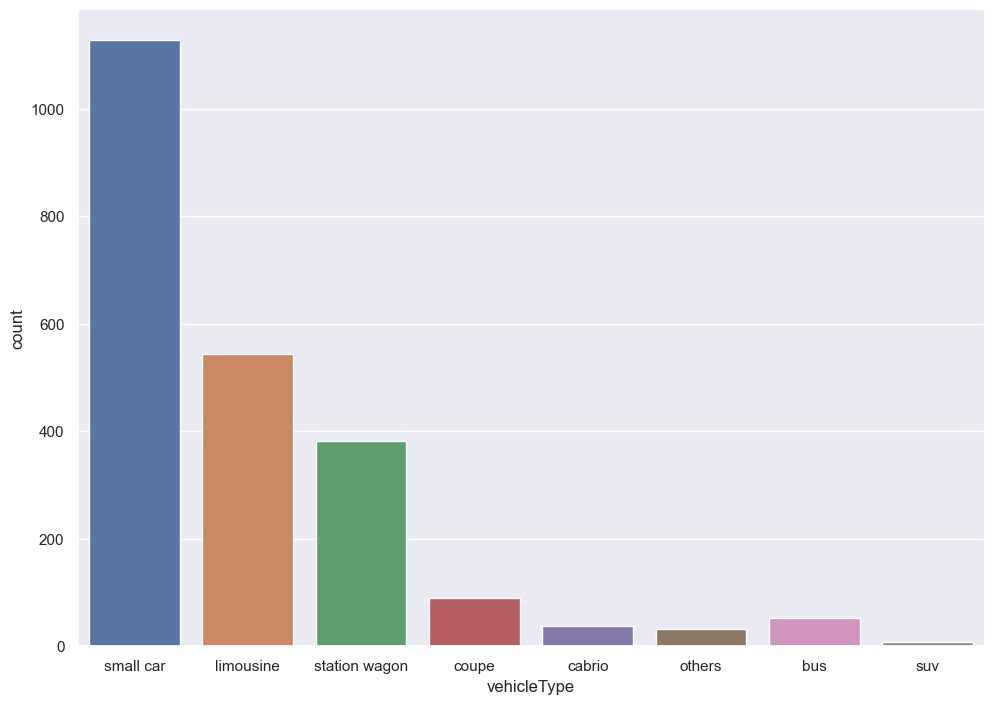

In [49]:
sns.countplot(x='vehicleType',data=cars)

<AxesSubplot:xlabel='vehicleType', ylabel='price'>

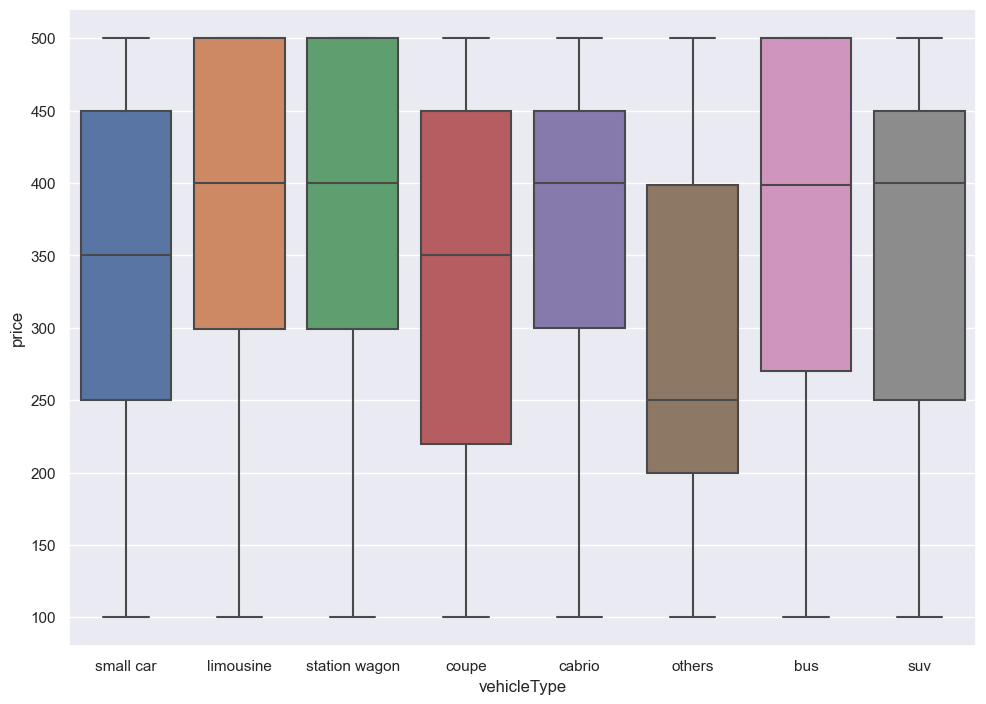

In [50]:
sns.boxplot(x='vehicleType',y='price',data=cars)

In [51]:
cars['gearbox'].value_counts()

manual       2397
automatic     197
Name: gearbox, dtype: int64

In [52]:
pd.crosstab(cars['gearbox'],columns='count',normalize=True)

col_0,count
gearbox,
automatic,0.076
manual,0.924


<AxesSubplot:xlabel='gearbox', ylabel='count'>

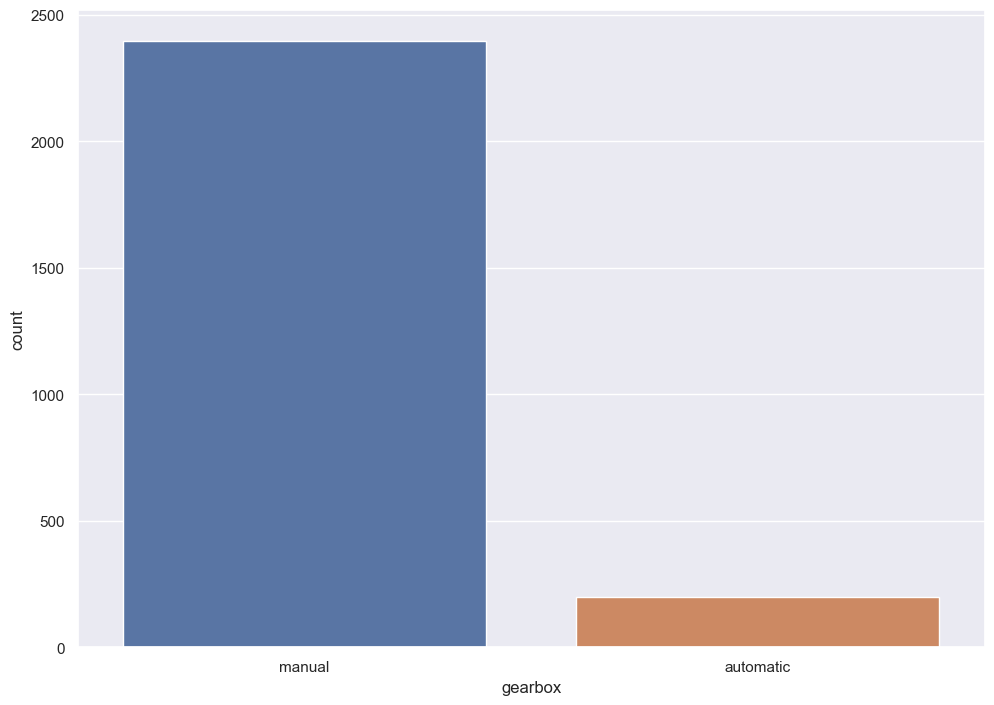

In [53]:
sns.countplot(x='gearbox',data=cars)

<AxesSubplot:xlabel='gearbox', ylabel='price'>

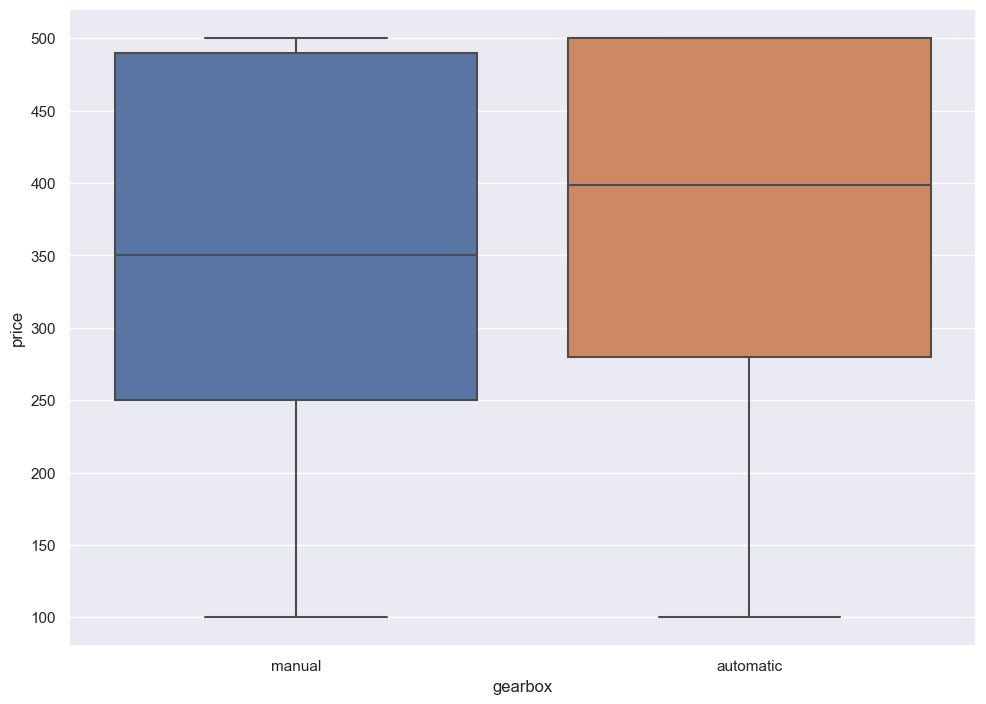

In [54]:
sns.boxplot(x='gearbox',y='price',data=cars)

In [55]:
cars['model'].value_counts()

golf        271
corsa       231
polo        222
others      175
astra       120
           ... 
a8            1
delta         1
leon          1
mx_reihe      1
grand         1
Name: model, Length: 109, dtype: int64

In [56]:
pd.crosstab(cars['model'],columns='count',normalize=True)

col_0,count
model,
100,0.002
145,0.001
147,0.000
156,0.004
1_reihe,0.011
...,...
v40,0.008
vectra,0.033
voyager,0.001


In [59]:
cars['kilometer'].value_counts()

150000    2249
125000     205
5000        63
100000      59
90000       43
80000       20
30000       19
20000       19
60000       14
70000       14
50000        8
40000        5
10000        2
Name: kilometer, dtype: int64

In [62]:
pd.crosstab(cars['kilometer'],columns='count',normalize=True,)

col_0,count
kilometer,
5000,0.023
10000,0.001
20000,0.007
30000,0.007
40000,0.002
50000,0.003
60000,0.005
70000,0.005
80000,0.007


C:\Users\srini\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='kilometer'>

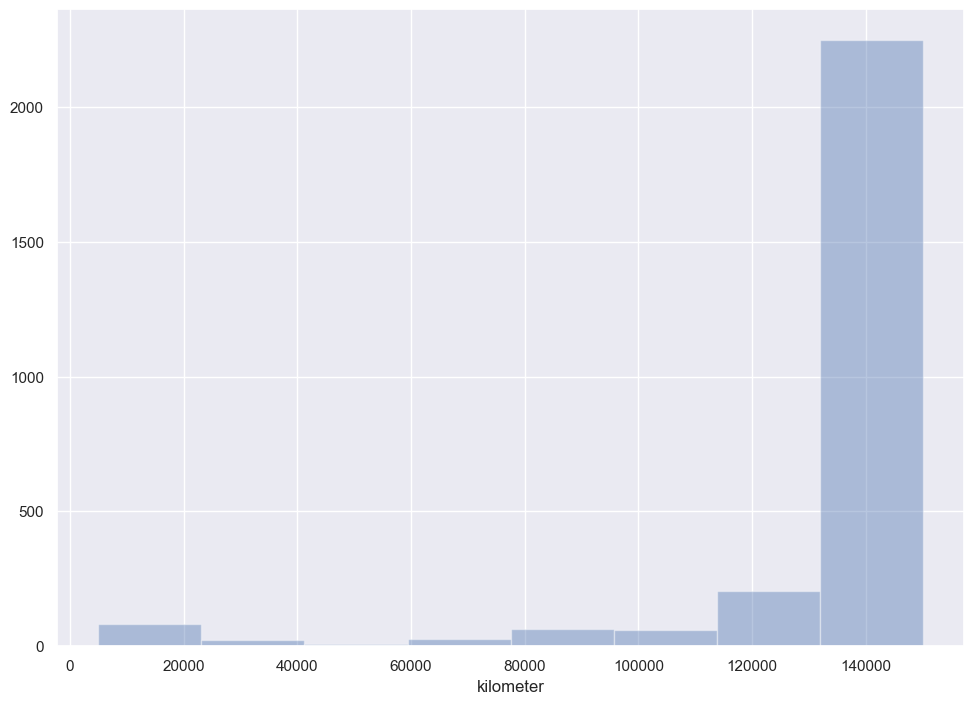

In [63]:
sns.distplot(cars['kilometer'],bins=8,kde=False)

<AxesSubplot:xlabel='kilometer', ylabel='price'>

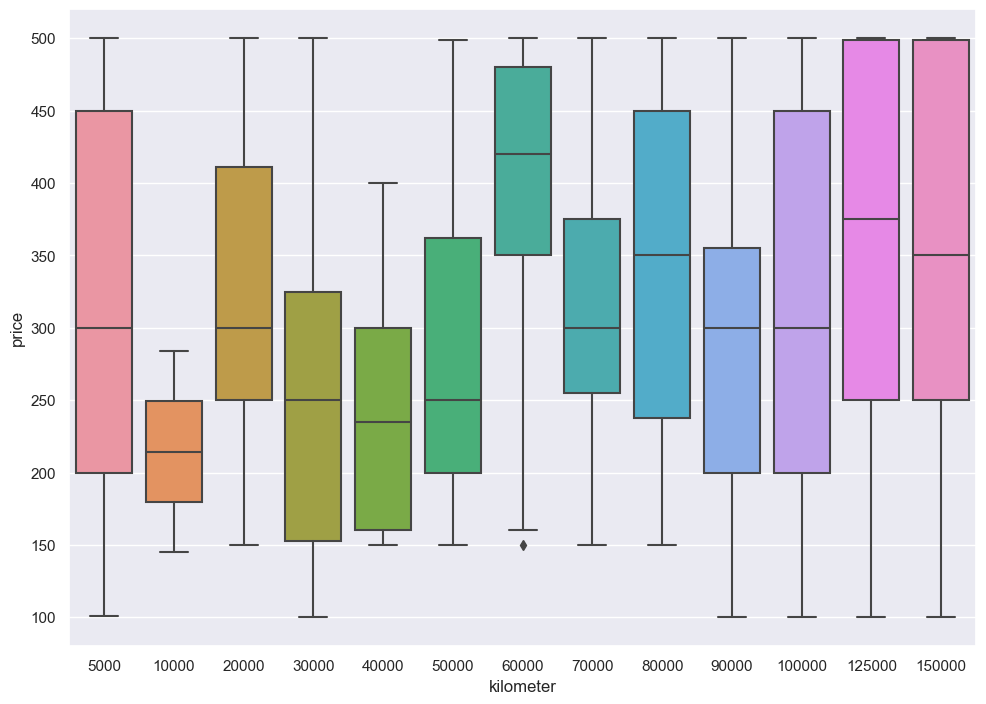

In [64]:
sns.boxplot(x='kilometer',y='price',data=cars)

<AxesSubplot:xlabel='kilometer', ylabel='price'>

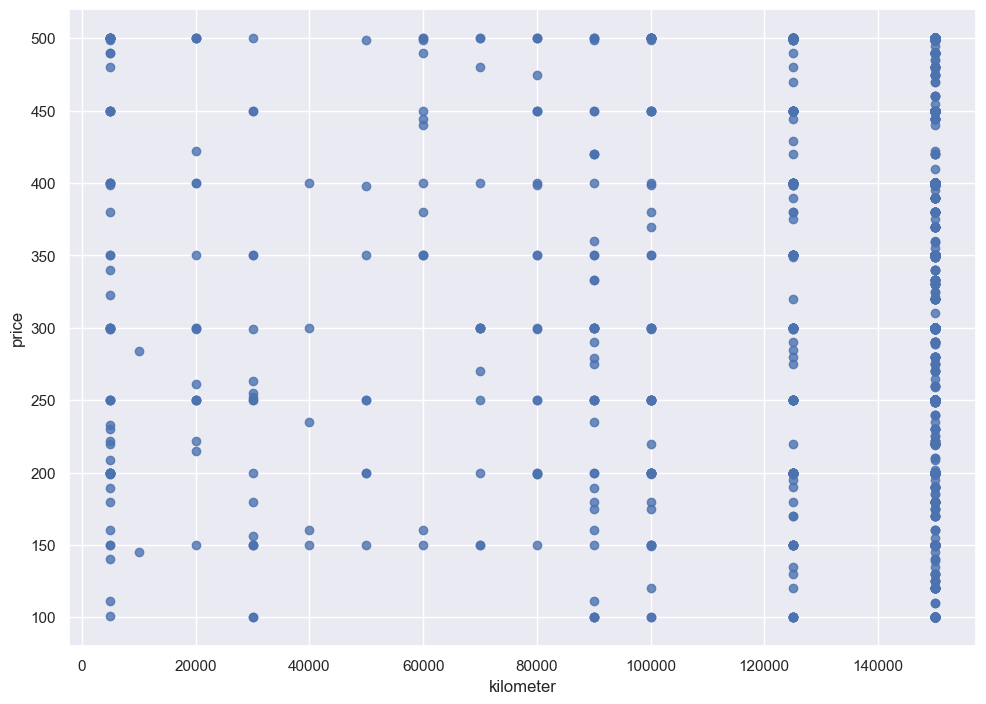

In [65]:
sns.regplot(x='kilometer',y='price',scatter=True,fit_reg=False,data=cars)

In [66]:
cars['fuelType'].value_counts()

petrol    2167
diesel     128
lpg         14
hybrid       1
Name: fuelType, dtype: int64

In [68]:
pd.crosstab(cars['fuelType'],columns='count',normalize=True)

col_0,count
fuelType,
diesel,0.055
hybrid,0.000
lpg,0.006
petrol,0.938


<AxesSubplot:xlabel='fuelType', ylabel='count'>

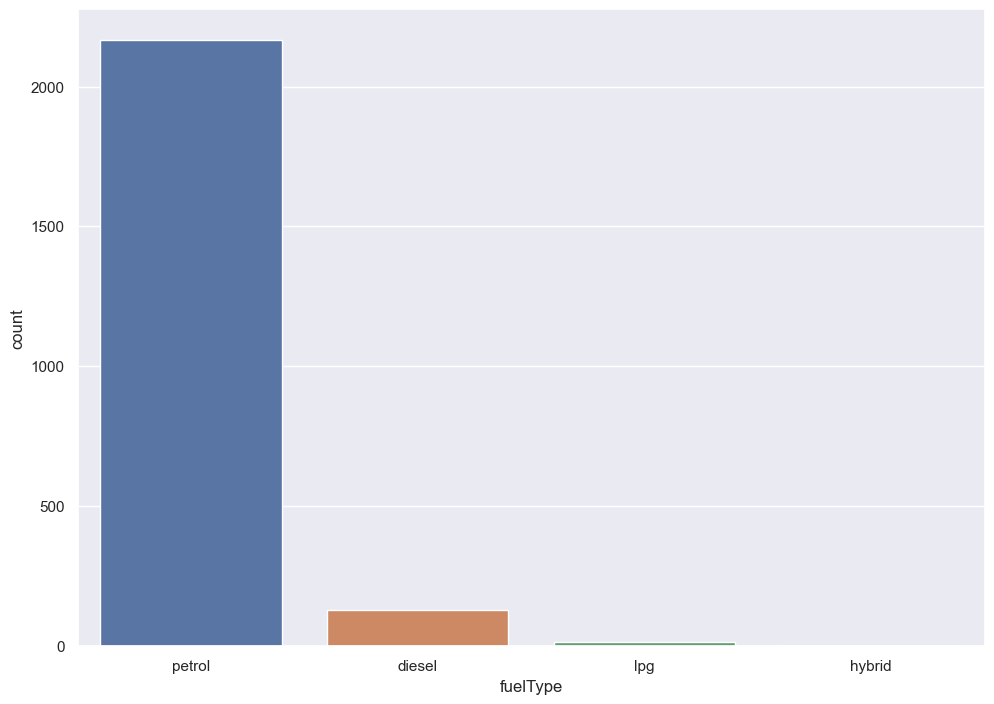

In [70]:
sns.countplot(x='fuelType',data=cars)

<AxesSubplot:xlabel='fuelType', ylabel='price'>

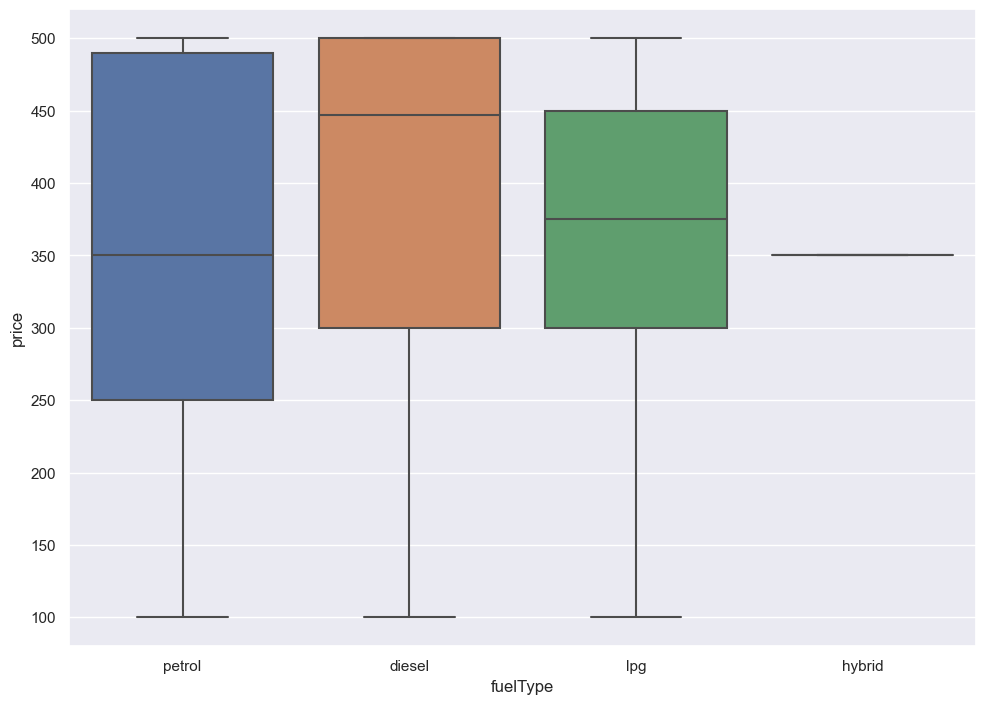

In [71]:
sns.boxplot(x='fuelType',y='price',data=cars)

In [72]:
cars['brand'].value_counts()

volkswagen        620
opel              523
ford              372
renault           231
fiat              119
audi              116
bmw               105
peugeot            86
seat               67
mercedes_benz      55
nissan             54
mazda              53
citroen            49
mitsubishi         46
volvo              30
honda              26
suzuki             18
hyundai            14
subaru             13
chrysler           13
alfa_romeo         12
toyota             12
daihatsu           11
kia                11
sonstige_autos     11
rover              10
daewoo             10
smart               9
skoda               8
lancia              6
saab                3
trabant             2
mini                2
chevrolet           2
porsche             1
Name: brand, dtype: int64

In [73]:
pd.crosstab(cars['brand'],columns='count',normalize=True)

col_0,count
brand,
alfa_romeo,0.004
audi,0.043
bmw,0.039
chevrolet,0.001
chrysler,0.005
citroen,0.018
daewoo,0.004
daihatsu,0.004
fiat,0.044


<AxesSubplot:xlabel='brand', ylabel='count'>

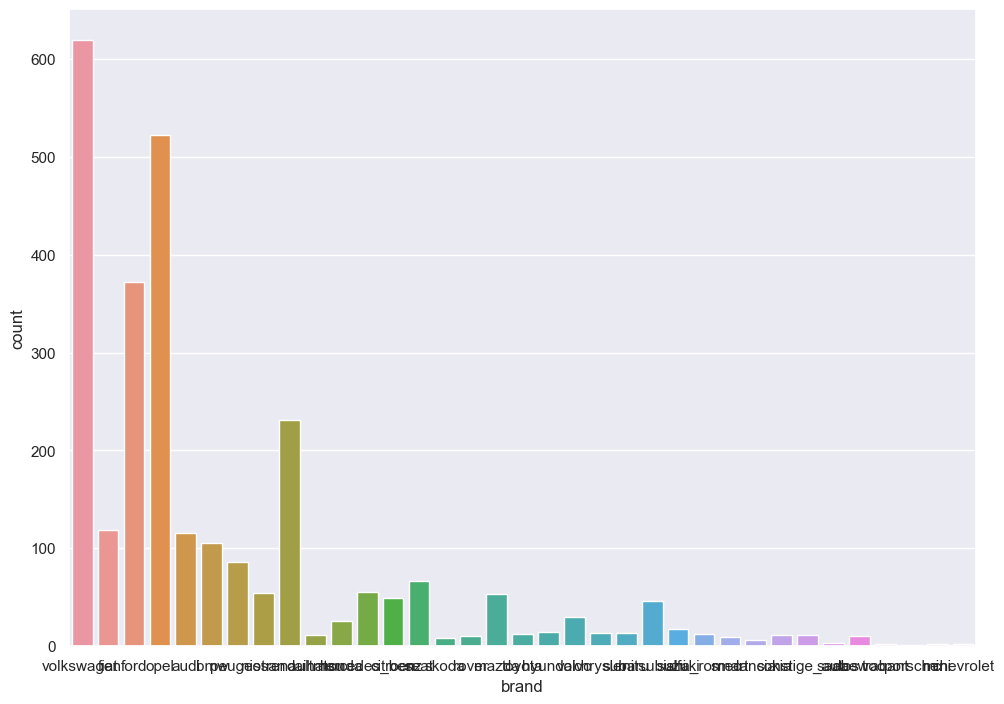

In [74]:
sns.countplot(x='brand',data=cars)

<AxesSubplot:xlabel='brand', ylabel='price'>

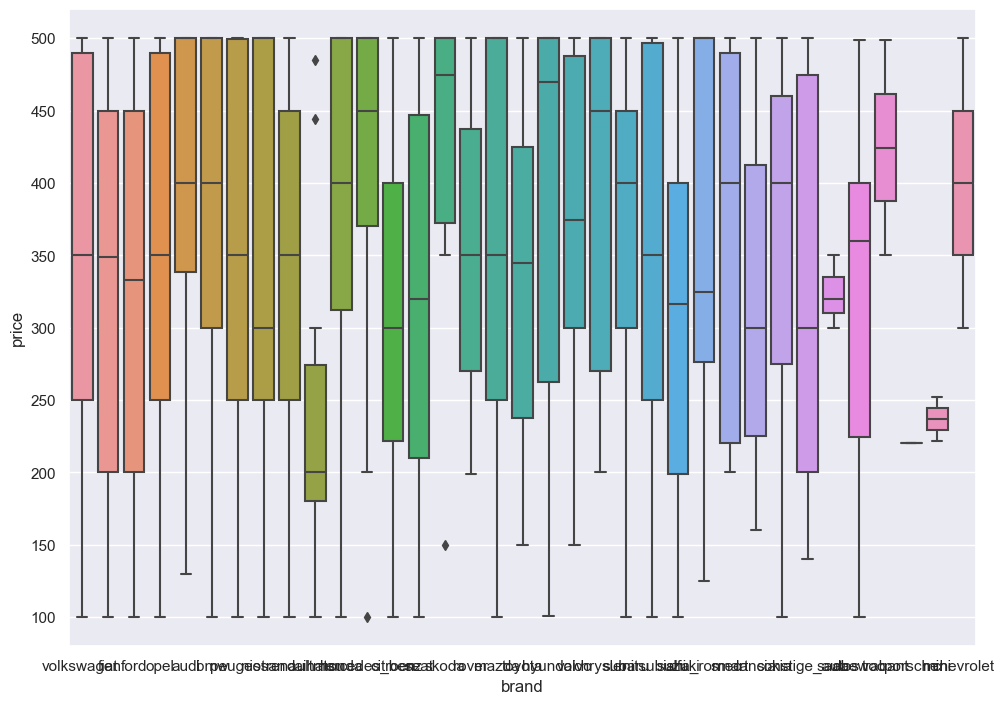

In [77]:
sns.boxplot(x='brand',y='price',data=cars)

In [80]:
cars['notRepairedDamage'].value_counts()

yes    984
no     880
Name: notRepairedDamage, dtype: int64

In [81]:
pd.crosstab(cars['notRepairedDamage'],columns='count',normalize=True)

col_0,count
notRepairedDamage,
no,0.472
yes,0.528


<AxesSubplot:xlabel='notRepairedDamage', ylabel='count'>

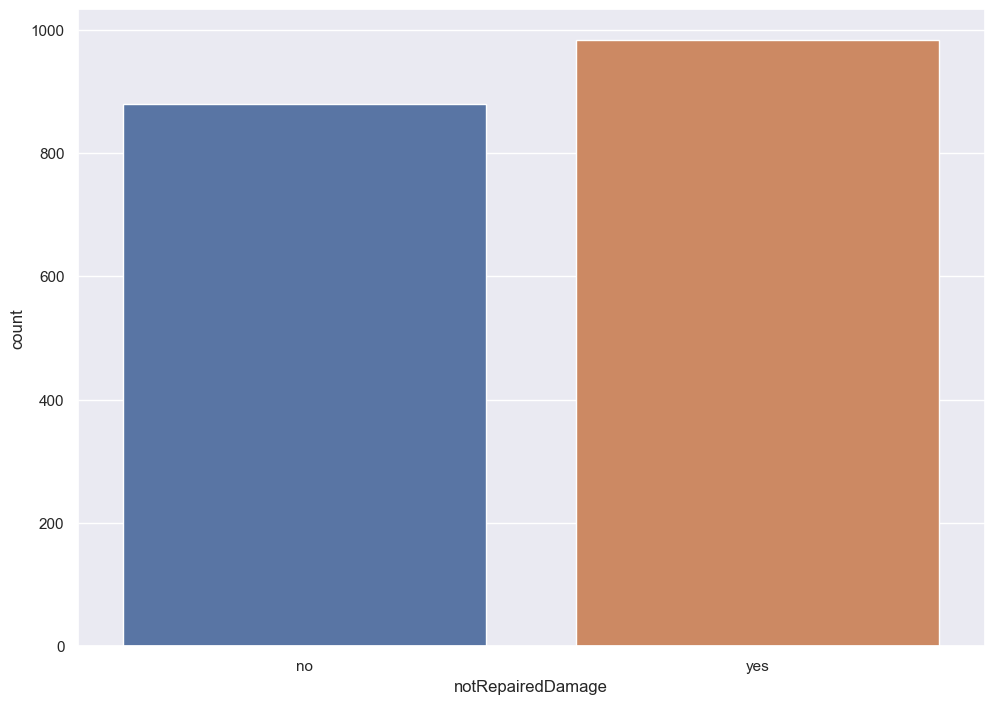

In [82]:
sns.countplot(x='notRepairedDamage',data=cars)

<AxesSubplot:xlabel='notRepairedDamage', ylabel='price'>

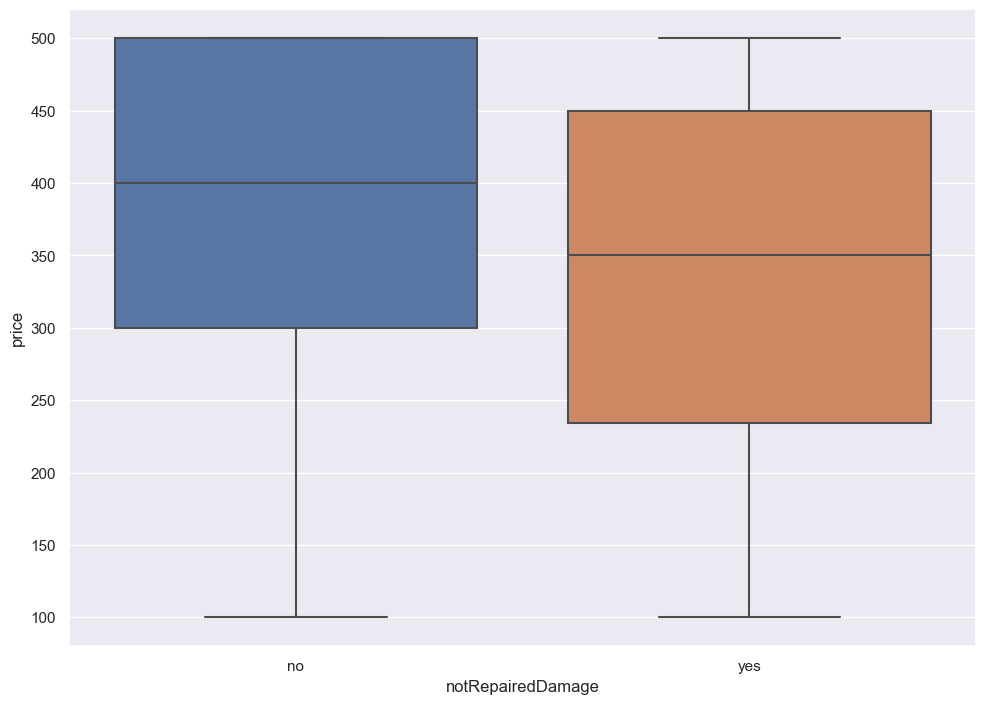

In [83]:
sns.boxplot(x='notRepairedDamage',y='price',data=cars)

In [84]:
col=['seller','offerType','abtest']

In [85]:
cars=cars.drop(columns=col,axis=1)

In [86]:
cars_copy=cars.copy()

In [88]:
cars_select1=cars.select_dtypes(exclude=[object])

In [89]:
cor=cars_select1.corr()

In [90]:
round(cor,3)

,price,powerPS,kilometer,Age
price,1.000,-0.006,0.082,0.004
powerPS,-0.006,1.000,-0.085,0.018
kilometer,0.082,-0.085,1.000,0.077
Age,0.004,0.018,0.077,1.000


In [91]:
cars_select1.corr().loc[:,'price'].abs().sort_values(ascending=False)[1:]

kilometer   0.082
powerPS     0.006
Age         0.004
Name: price, dtype: float64

In [93]:
cars_omit=cars.dropna(axis=0)